# A3.9 Example: A Flashing Beacon on the Millennium Falcon

## A3.9.1 The Scenario

The **Millennium Falcon** is traveling at a constant speed of $v = 0.6c$ past a stationary observation post on the forest moon of Endor.

- At the moment the Falcon passes directly in front of the post (call this Event O at $t=0$, $x=0$), it begins emitting **a flash of light once per second**, according to **its own onboard clock**.

- An observer on Endor (stationary frame) watches the ship pass by and sees the flashes.

---

### Your Tasks

1. **Plot the worldline of the Millennium Falcon**.
2. **Add the light flashes** as dots along its worldline — in the Falcon’s frame, they are one second apart.
3. **Transform those flashes** to the **stationary frame** and mark when and where they occur.
4. **Discuss what the stationary observer sees**:
   - Are the flashes equally spaced in time?
   - Are they equally spaced in space?

This problem combines:
- Spacetime diagrams
- Lorentz transformations
- Time dilation
- Relativity of simultaneity
  
<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## A3.9.2 Solution
Let’s begin by visualizing the Falcon’s worldline and flash events.


**🐍 Jupyter Python Code Cell — Plot the Worldline and Flash Events in Moving Frame**

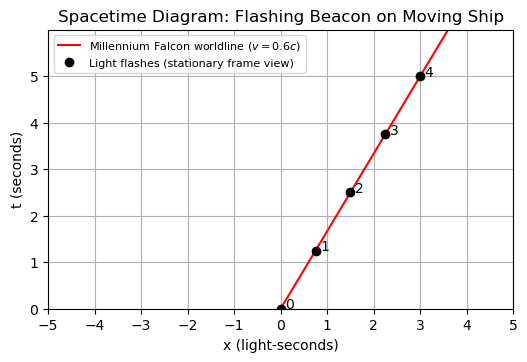

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Falcon speed and gamma
v = 0.6
gamma = 1 / np.sqrt(1 - v**2)

# Proper time interval between flashes (Falcon's frame)
delta_tau = 1
n_flashes = 5

# Flash events in Falcon frame (each at x'=0)
tau_prime = np.array([i * delta_tau for i in range(n_flashes)])
x_prime = np.zeros_like(tau_prime)

# Lorentz transform to stationary frame
t = gamma * (tau_prime + v * x_prime)  # Since x'=0, this is just gamma * tau
x = gamma * (x_prime + v * tau_prime)  # = gamma * v * tau

# Worldline and flashes
t_vals = np.linspace(0, 6, 100)
x_vals = v * t_vals

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

# Falcon worldline
ax.plot(x_vals, t_vals, 'r-', label='Millennium Falcon worldline ($v = 0.6c$)')

# Flash events (in stationary frame)
ax.plot(x, t, 'ko', label='Light flashes (stationary frame view)')

# Annotations
for i in range(n_flashes):
    ax.annotate(f"{i}", (x[i] + 0.1, t[i]))

# Formatting
ax.set_xlim(0, 5)
ax.set_ylim(0, 6)
ax.set_xlabel("x (light-seconds)")
ax.set_ylabel("t (seconds)")
ax.set_title("Spacetime Diagram: Flashing Beacon on Moving Ship")
ax.grid(True)

ax.set_aspect('equal')

# Force ticks at integer grid points
ax.set_xticks(np.arange(-5, 6, 1))
ax.set_yticks(np.arange(0, 6, 1))
ax.legend(loc='upper left', fontsize=8, frameon=True)

plt.show()


### Interpretation: What Does Endor See?

- The **red line** is the **worldline of the Millennium Falcon**.
- The **black dots** are the locations (in spacetime) where the Falcon emits light flashes.
  - In the Falcon's own frame, these occur once per second.
  - But due to time dilation, the Endor observer sees them spaced at:

    $$
    \Delta t = \gamma \cdot \Delta \tau = 1.25 \cdot 1 = 1.25 \text{ s}
    $$

---

#### Spatial Separation?

- The flashes are **not only delayed** — they are also **spatially spread out** in the stationary frame.
- The distance between two successive flashes is:

  $$
  \Delta x = v \cdot \Delta t = 0.6c \cdot 1.25 = 0.75 \text{ light-seconds}
  $$

So each flash is emitted **further along the $x$-axis** and **slightly later in time** compared to the previous one.

---

#### Visual Summary

> ✅ A clock on the Falcon ticks once per second, but to the Endor observer:
> - Each tick takes **1.25 seconds**.
> - And comes from a position **0.75 light-seconds** further along.

This spacetime diagram shows **how time dilation and motion work together** to affect the appearance of a moving flashing source.

**🐍 Python Code Cell — Plot Flash Emissions and When They Are Observed**

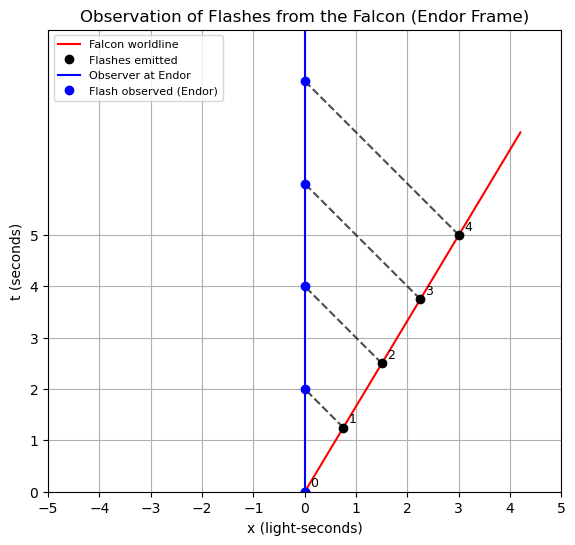

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
v = 0.6
gamma = 1 / np.sqrt(1 - v**2)
delta_tau = 1
n_flashes = 5

# Emission events in moving frame (each at x'=0)
tau_prime = np.array([i * delta_tau for i in range(n_flashes)])
x_prime = np.zeros_like(tau_prime)

# Transform to stationary frame
t_emit = gamma * tau_prime
x_emit = gamma * v * tau_prime

# When each flash reaches the observer at x = 0 (Endor)
t_obs = t_emit + x_emit  # Since light travels back at speed c = 1

# Set up plot
fig, ax = plt.subplots(figsize=(7, 6))

# Plot worldline of Falcon
t_vals = np.linspace(0, 7, 100)
x_falcon = v * t_vals
ax.plot(x_falcon, t_vals, 'r-', label='Falcon worldline')

# Plot flash emission points
ax.plot(x_emit, t_emit, 'ko', label='Flashes emitted')

# Plot light rays arriving at Endor (x = 0)
for i in range(n_flashes):
    ax.plot([x_emit[i], 0], [t_emit[i], t_obs[i]], 'k--', alpha=0.7)
    ax.annotate(f"{i}", (x_emit[i]+0.1, t_emit[i]+0.1), fontsize=9)

# Plot observer worldline at x=0
ax.plot([0, 0], [0, max(t_obs)+1], 'b-', label='Observer at Endor')

# Observed arrival times as blue dots
ax.plot(np.zeros_like(t_obs), t_obs, 'bo', label='Flash observed (Endor)')

# Labels and formatting
ax.set_xlabel("x (light-seconds)")
ax.set_ylabel("t (seconds)")
ax.set_title("Observation of Flashes from the Falcon (Endor Frame)")

ax.grid(True)
ax.set_xlim(-0.5, max(x_emit)+1)
ax.set_ylim(0, max(t_obs)+1)
ax.set_aspect('equal')

# Force ticks at integer grid points
ax.set_xticks(np.arange(-5, 6, 1))
ax.set_yticks(np.arange(0, 6, 1))
ax.legend(loc='upper left', fontsize=8, frameon=True)

plt.show()


### Interpretation: When Are the Flashes Seen on Endor?

This plot shows:

- **Black dots**: where and when each flash was **emitted**.
- **Blue dots**: when each flash is actually **seen** by the observer at $x = 0$.
- **Dashed black lines**: paths of light rays traveling back at speed $c = 1$.

---

### What We See

| Flash # | Emission Time (s) | Emission Position (ls) | Observed at (s) |
|---------|-------------------|-------------------------|------------------|
| 0       | 0.00              | 0.00                    | 0.00             |
| 1       | 1.25              | 0.75                    | 2.00             |
| 2       | 2.50              | 1.50                    | 4.00             |
| 3       | 3.75              | 2.25                    | 6.00             |
| 4       | 5.00              | 3.00                    | 8.00             |

---

### What This Tells Us

- Even though the flashes were emitted **1.25 seconds apart** (as measured on Endor), they are seen **2 seconds apart** due to:
  - **Time dilation** (slower clock on Falcon)
  - **Travel delay** (each flash is farther away)

This is a visual demonstration of the **relativistic Doppler effect** in action — even though the Falcon flashes once per second in its own frame, Endor sees a lower frequency of flashes.

---

> **Key Insight**: Spacetime diagrams allow you to **separate emission from observation** — and explain why even perfectly regular events in one frame appear distorted in another.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">